# CUSTOMER LIFETIME VALUE

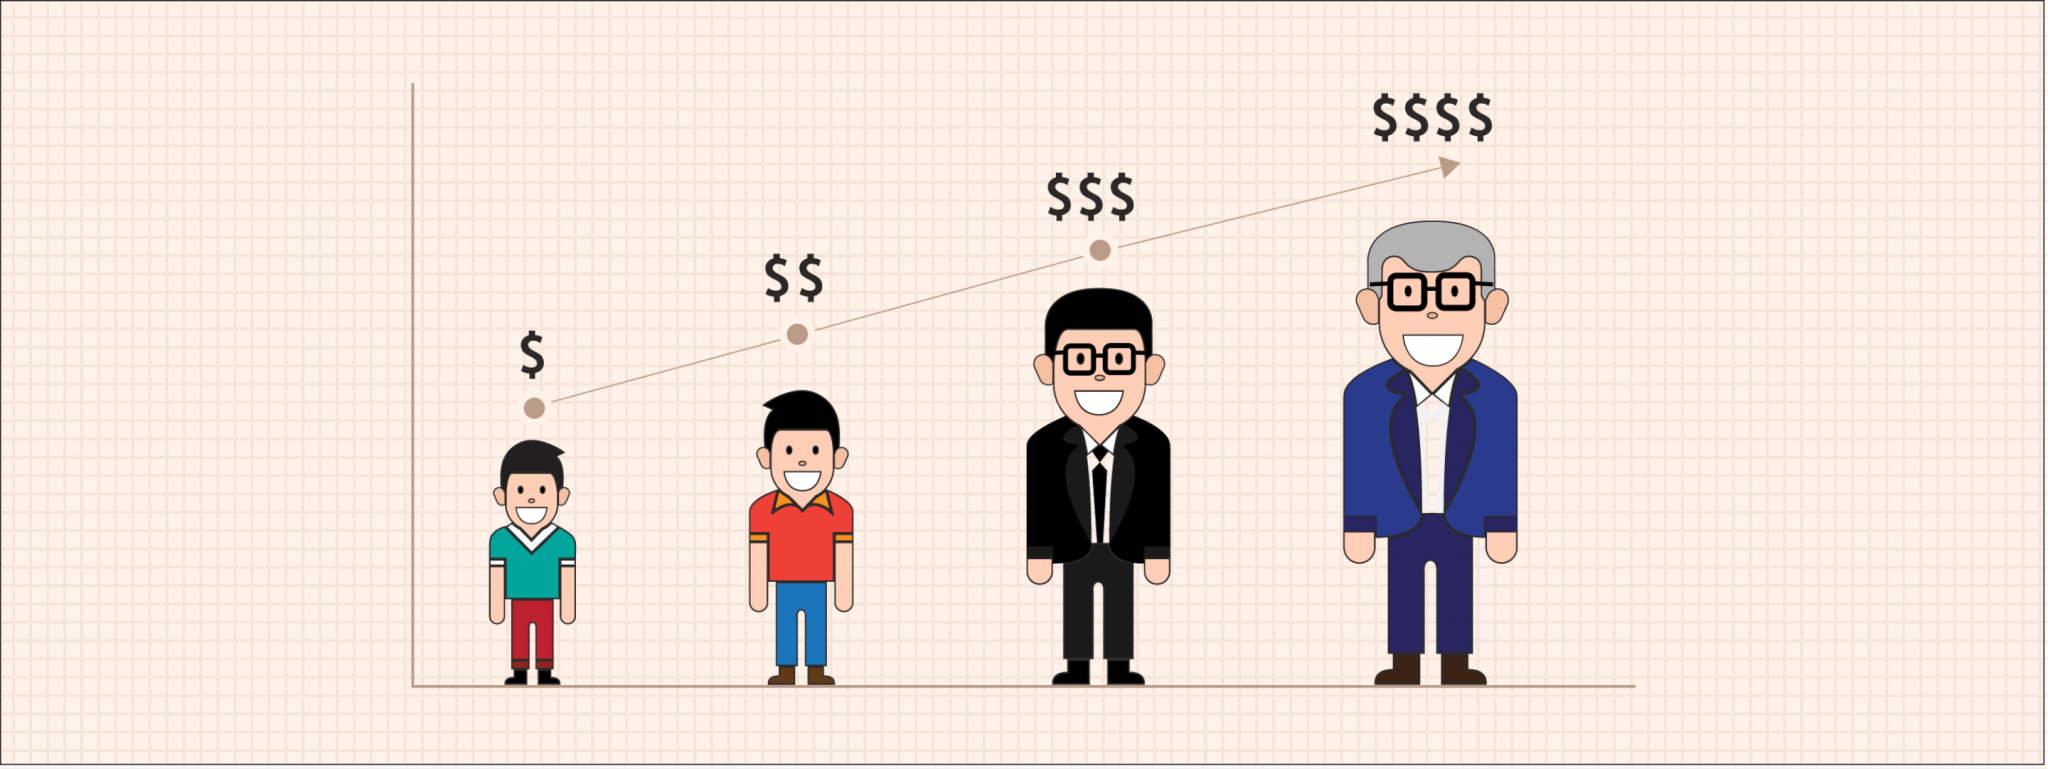

# Customer Lifetime Value (CLTV)

Customer Lifetime Value (CLTV) predicts the **total potential revenue** a customer may generate throughout their relationship with the company.  
By calculating the lifetime value of existing customers, we can compare it with the cost of acquiring new customers and make informed decisions on balancing retention and acquisition.

---

## Why Do We Need It?
1. Understand Customer Value  
2. Optimize Marketing and Sales Budgets  
3. Customer Segmentation and Personalization  
4. Forecast Future Revenue  
5. Guide Business Strategies  

---

## How is it Calculated?

$$
\text{CLTV} = \frac{\text{Customer Value}}{\text{Churn Rate}} \times \text{Profit Margin}
$$

### Customer Value

Customer Value is calculated as:

$$
\text{Customer Value} = \text{Average Order Value} \times \text{Purchase Frequency}
$$

---

## Definitions

- **Churn Rate**: The rate at which customers leave.  
$$
\text{Churn Rate} = 1 - \text{Repeat Rate}
$$

- **Profit Margin**: The profit assumed on customer transactions.  
$$
\text{Profit Margin} = \text{Total Price} \times 0.10
$$

- **Average Order Value (AOV)**: Average revenue per order.  
$$
\text{Average Order Value} = \frac{\text{Total Price}}{\text{Total Transactions}}
$$

- **Purchase Frequency**: How often a customer purchases.  
$$
\text{Purchase Frequency} = \frac{\text{Total Transactions}}{\text{Total Number of Customers}}
$$

- **Repeat Rate**: The proportion of customers who make repeat purchases.  
$$
\text{Repeat Rate} = \frac{\text{Number of Customers with Multiple Purchases}}{\text{Total Number of Customers}}
$$


## CLTV Prediction

CLTV Prediction estimates the **total potential revenue** a customer may generate for a company in the future.

$$
\text{CLTV} = \text{Expected Number of Transactions} \times \text{Expected Average Profit}
$$

Customer purchasing behavior is modeled probabilistically, and predictions are made **conditionally** for each individual customer.

### Advantages of CLTV Prediction
1. Direct marketing budgets toward high-value customers  
2. Identify high churn-risk customers in advance  
3. Enable personalized campaigns and segmentation  
4. Forecast long-term revenue  

---

## Models

### 1️⃣ BG/NBD Model
- **Transaction Process:** Customers make transactions according to a Poisson distribution while active.  
- **Dropout Process:** The probability of a customer becoming inactive follows a Beta distribution.  
- Parameters:  
  - \(x\) = number of transactions  
  - \(t\) = recency (time since last purchase)  
  - \(T\) = customer age (time since first purchase)  
  - \(r, a\) = variation in transaction rate  
  - \(α, β\) = inactivity probability  

### 2️⃣ Gamma-Gamma Submodel
- Predicts the **average profit per transaction** for a customer.  
- Transaction values across customers follow a Gamma distribution.

---

**Summary:**  
- BG/NBD → Predicts the expected number of transactions  
- Gamma-Gamma → Predicts the expected profit per transaction  
- CLTV → Calculated as the product of these two predictions to estimate individual customer lifetime value


In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
from sklearn.preprocessing import MinMaxScaler

In [5]:
sales = pd.read_csv("Dataset/Cleaned_data/clean_sales.csv")
discounts = pd.read_csv("Dataset/Cleaned_data/clean_discount.csv")
tax = pd.read_csv("Dataset/Cleaned_data/clean_tax.csv")
customers =pd.read_csv("Dataset/Cleaned_data/clean_customers.csv")

market=pd.read_csv("Dataset/Cleaned_data/clean_marketing.csv")


In [6]:
df =customers.merge(sales,on='CustomerID')
df.head()

,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,Jan
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,Jan
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,Jan


In [7]:
df =df.merge(tax,on='Product_Category')
df.head()

,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,GST
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,0.10
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,0.10
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,Jan,0.10
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,Jan,0.18
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,Jan,0.18


In [8]:
df.info()
df.describe().T



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Gender               52924 non-null  object 
 2   Location             52924 non-null  object 
 3   Tenure_Months        52924 non-null  int64  
 4   Transaction_ID       52924 non-null  int64  
 5   Transaction_Date     52924 non-null  object 
 6   Product_SKU          52924 non-null  object 
 7   Product_Description  52924 non-null  object 
 8   Product_Category     52924 non-null  object 
 9   Quantity             52924 non-null  int64  
 10  Avg_Price            52924 non-null  float64
 11  Delivery_Charges     52924 non-null  float64
 12  Coupon_Status        52924 non-null  object 
 13  Month                52924 non-null  object 
 14  GST                  52924 non-null  float64
dtypes: float64(3), int64(4), object(8)
m

,count,mean,std,min,25%,50%,75%,max
CustomerID,52924.0,15346.709810,1766.556020,12346.00,13869.0,15311.00,16996.25,18283.00
Tenure_Months,52924.0,26.127995,13.478285,2.00,15.0,27.00,37.00,50.00
Transaction_ID,52924.0,32409.825675,8648.668977,16679.00,25384.0,32625.50,39126.25,48497.00
Quantity,52924.0,4.497638,20.104711,1.00,1.0,1.00,2.00,900.00
Avg_Price,52924.0,52.237646,64.006882,0.39,5.7,16.99,102.13,355.74
Delivery_Charges,52924.0,10.517630,19.475613,0.00,6.0,6.00,6.50,521.36
GST,52924.0,0.137462,0.045825,0.05,0.1,0.18,0.18,0.18


In [9]:
df['Total_Price'] = (df['Quantity'] * df['Avg_Price']) + df['Delivery_Charges'] + (df['Quantity'] * df['Avg_Price'] * df['GST'])
df.head()

,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,GST,Total_Price
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,0.10,175.581
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,0.10,175.581
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,Jan,0.10,8.755
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,Jan,0.18,109.927
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,Jan,0.18,25.970


In [10]:

df["coupon_used"] = df["Coupon_Status"].apply(lambda x: 1 if x == "Used" else 0)

df["effective_price"] = df["Total_Price"] * (1 - df["GST"])

coupon_freq = df.groupby("CustomerID")["coupon_used"].sum().reset_index()
coupon_freq.columns = ["CustomerID", "coupon_frequency"]

coupon_freq["segment"] = coupon_freq["coupon_frequency"].apply(
    lambda x: "Loyal (uses coupons often)" if x > 3 else "Occasional"
)

df = df.merge(coupon_freq, on="CustomerID", how="left")


df.head()


,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,GST,Total_Price,coupon_used,effective_price,coupon_frequency,segment
0,17850,M,Chicago,12,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,0.10,175.581,1,158.02290,91,Loyal (uses coupons often)
1,17850,M,Chicago,12,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,Jan,0.10,175.581,1,158.02290,91,Loyal (uses coupons often)
2,17850,M,Chicago,12,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,Jan,0.10,8.755,1,7.87950,91,Loyal (uses coupons often)
3,17850,M,Chicago,12,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,Jan,0.18,109.927,0,90.14014,91,Loyal (uses coupons often)
4,17850,M,Chicago,12,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,Jan,0.18,25.970,1,21.29540,91,Loyal (uses coupons often)


## CLTV Prediction

In [12]:
df["Transaction_Date"].max()

today_date = dt.datetime(year=2020, month=1, day=2)
df["Transaction_Date"] = df["Transaction_Date"].apply(pd.to_datetime)
df = df[df["Quantity"] > 0]
df = df[df["effective_price"] > 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  int64         
 1   Gender               52924 non-null  object        
 2   Location             52924 non-null  object        
 3   Tenure_Months        52924 non-null  int64         
 4   Transaction_ID       52924 non-null  int64         
 5   Transaction_Date     52924 non-null  datetime64[ns]
 6   Product_SKU          52924 non-null  object        
 7   Product_Description  52924 non-null  object        
 8   Product_Category     52924 non-null  object        
 9   Quantity             52924 non-null  int64         
 10  Avg_Price            52924 non-null  float64       
 11  Delivery_Charges     52924 non-null  float64       
 12  Coupon_Status        52924 non-null  object        
 13  Month                52924 non-

In [13]:
cltv_p = pd.DataFrame()
cltv_p = df.groupby("CustomerID").agg({
    "Transaction_Date": [lambda x: (x.max() - x.min()).days,
                         lambda x: (today_date - x.min()).days],
    "Transaction_ID": lambda x: x.nunique(),
    "effective_price": lambda x: x.sum()
})

cltv_p.columns = cltv_p.columns.droplevel(0)
cltv_p.columns = ['recency', 'T', 'frequency', 'monetary']
cltv_p.head()


,recency,T,frequency,monetary
CustomerID,,,,
12346,0,109,1,159.232324
12347,223,284,31,14079.004170
12348,119,194,8,1577.052936
12350,0,19,11,1454.927384
12356,0,109,13,1953.495716


In [14]:
cltv_p["monetary"] = cltv_p["monetary"] / cltv_p["frequency"]

cltv_p = cltv_p[(cltv_p['frequency'] > 1)]
cltv_p = cltv_p[(cltv_p['recency'] > 1)]
cltv_p["recency"] = cltv_p["recency"] / 7
cltv_p["T"] = cltv_p["T"] / 7
cltv_p.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,617.0,21.848113,13.573795,0.285714,10.857143,20.714286,31.857143,51.142857
T,617.0,36.667284,11.552632,3.571429,28.857143,39.000000,46.571429,52.285714
frequency,617.0,28.021070,33.356952,2.000000,10.000000,19.000000,35.000000,328.000000
monetary,617.0,185.068355,105.086187,14.562812,138.888942,172.813902,206.363201,1292.867922


In [15]:
# Creating BG-NBD Model

bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(cltv_p['frequency'],
        cltv_p['recency'],
        cltv_p['T'])


bgf.conditional_expected_number_of_purchases_up_to_time(1,
                                                        cltv_p['frequency'],
                                                        cltv_p['recency'],
                                                        cltv_p['T']).sort_values(ascending=False).head(10)

cltv_p["expected_purc_1_month"] = bgf.predict(4,
                                               cltv_p['frequency'],
                                               cltv_p['recency'],
                                               cltv_p['T'])


cltv_p["expected_purc_3_month"] = bgf.predict(4 * 3,
                                               cltv_p['frequency'],
                                               cltv_p['recency'],
                                               cltv_p['T'])

In [16]:
#Creating GAMMA-GAMMA Model

ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(cltv_p['frequency'], cltv_p['monetary'])

cltv_p["expected_average_profit"] = ggf.conditional_expected_average_profit(cltv_p['frequency'],
                                                                             cltv_p['monetary'])

In [17]:
cltv_f = ggf.customer_lifetime_value(bgf,
                                   cltv_p['frequency'],
                                   cltv_p['recency'],
                                   cltv_p['T'],
                                   cltv_p['monetary'],
                                   time=4 * 3 ,  
                                   freq="W",  
                                   discount_rate=0.01)

cltv_f = cltv_f.reset_index()
cltv_f.head()

cltv_final = cltv_p.merge(cltv_f , on="CustomerID" , how="left")

cltv_final.sort_values(by="clv", ascending=False).head(10)

,CustomerID,recency,T,frequency,monetary,expected_purc_1_month,expected_purc_3_month,expected_average_profit,clv
237,14606,49.857143,50.142857,289,214.690786,22.200110,63.761913,214.809612,47318.890189
360,15808,44.428571,44.857143,123,208.155693,10.522408,30.128230,208.427558,21495.454019
98,13113,37.714286,39.000000,29,713.898543,2.822219,8.089107,717.530806,19932.824938
442,16745,3.428571,3.857143,28,203.730371,16.312855,38.684461,204.906876,19396.304456
194,14180,46.714286,49.142857,41,540.090086,2.990404,8.627246,542.054833,16380.286414
223,14462,23.000000,24.142857,39,217.601140,5.725090,15.983886,218.495014,11179.611487
503,17315,26.142857,27.142857,51,173.568224,6.765495,18.975634,174.128923,10696.951974
581,17975,36.857143,39.857143,35,373.182415,2.808583,8.046108,374.809157,10341.336184
441,16725,45.714286,46.714286,67,186.339043,5.434087,15.613340,186.792535,10087.506061
86,13050,39.285714,40.142857,60,182.951250,5.656156,16.158892,183.449782,10082.095536


In [18]:
cltv_final["segment"] = pd.qcut(cltv_final["clv"], 4, labels=["D", "C", "B", "A"])
cltv_final.sort_values(by="clv", ascending=False).head(50)

cltv_final.groupby("segment").agg(
    {"count", "mean", "sum"})


CustomerID                          recency                   \
               sum count          mean          sum count       mean   
segment                                                                
D          2380944   155  15360.929032  1694.285714   155  10.930876   
C          2353985   154  15285.616883  2707.571429   154  17.581633   
B          2360072   154  15325.142857  3786.000000   154  24.584416   
A          2351842   154  15271.701299  5292.428571   154  34.366419   

                   T                  frequency  ... expected_purc_1_month  \
                 sum count       mean       sum  ...                  mean   
segment                                          ...                         
D        5365.857143   155  34.618433      5722  ...          6.673795e-08   
C        5508.857143   154  35.771800      3835  ...          2.297502e-03   
B        5863.000000   154  38.071429      2986  ...          2.248794e-01   
A        5886.000000   154  38.220779      4746  ...          2.144383e+00   

        expected_purc_3_month                     expected_average_profit  \
                          sum count          mean                     sum   
segment                                                                     
D                    0.000029   155  1.901750e-07            28640.192362   
C                    1.012183   154  6.572620e-03            26461.600268   
B                   99.542940   154  6.463827e-01            27101.444256   
A                  936.542661   154  6.081446e+00            33508.211782   

                                     clv                     
        count        mean            sum count         mean  
segment                                                      
D         155  184.775435       0.015690   155     0.000101  
C         154  171.828573     440.531186   154     2.860592  
B         154  175.983404   49977.014093   154   324.526066  
A         154  217.585791  657578.636606   154  4269.991147  

[4 rows x 27 columns]

In [19]:
from lifetimes.utils import calibration_and_holdout_data

# 1. Đảm bảo đúng định dạng ngày
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# 2. Tính toán mốc thời gian tự động (ví dụ: lấy 80% dữ liệu để học)
start_date = df['Transaction_Date'].min()
end_date = df['Transaction_Date'].max()
duration = (end_date - start_date).days
cal_end = start_date + pd.Timedelta(days=int(duration * 0.8))

# 3. Chia dữ liệu với mốc thời gian thực tế
summary_cal_holdout = calibration_and_holdout_data(df, 
                                                   customer_id_col='CustomerID', 
                                                   datetime_col='Transaction_Date',
                                                   monetary_value_col='Total_Price',
                                                   calibration_period_end=cal_end, 
                                                   observation_period_end=end_date)

print(f"Giai đoạn huấn luyện kết thúc vào: {cal_end}")
print(summary_cal_holdout.head())

Giai đoạn huấn luyện kết thúc vào: 2019-10-19 00:00:00
            frequency_cal  recency_cal  T_cal  monetary_value_cal  \
CustomerID                                                          
12346                 0.0          0.0   34.0              0.0000   
12347                 0.0          0.0  209.0              0.0000   
12348                 1.0        119.0  119.0            859.0082   
12356                 0.0          0.0   34.0              0.0000   
12359                 0.0          0.0   57.0              0.0000   

            frequency_holdout  monetary_value_holdout  duration_holdout  
CustomerID                                                               
12346                     0.0                0.000000              73.0  
12347                     2.0              106.542241              73.0  
12348                     0.0                0.000000              73.0  
12356                     0.0                0.000000              73.0  
12359            

In [20]:
from lifetimes import BetaGeoFitter

# Huấn luyện mô hình trên dữ liệu Calibration
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary_cal_holdout['frequency_cal'], 
        summary_cal_holdout['recency_cal'], 
        summary_cal_holdout['T_cal'])

<lifetimes.BetaGeoFitter: fitted with 1261 subjects, a: 0.40, alpha: 63.05, b: 1.02, r: 0.59>

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

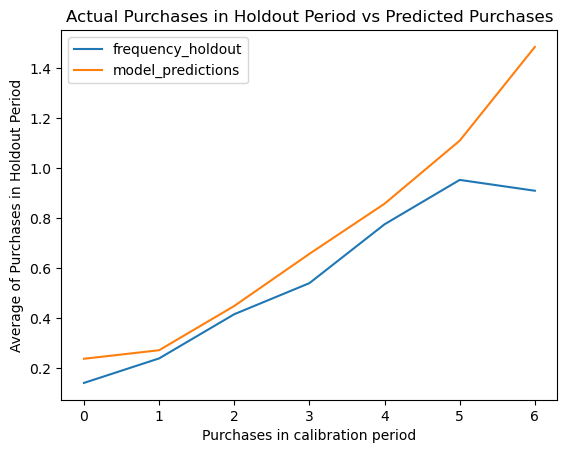

In [21]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

# Vẽ biểu đồ kiểm định
plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)